# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [1]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [2]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# causal-learn
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import fisherz

# Data generation
from src.generate_scm import *

np.random.seed(2)


# -------------------------------------------------------
# Helpers: extract pandas adjacency matrices from causal-learn
# -------------------------------------------------------
def get_adjacency_pc(cg, col_names):
    """
    Extract adjacency matrix from a causal-learn PC CausalGraph.

    causal-learn CPDAG encoding in cg.G.graph[i, j]:
      Directed  i --> j : graph[i, j] == -1  and  graph[j, i] == 1
      Undirected i -- j : graph[i, j] == -1  and  graph[j, i] == -1

    We set adj[i, j] = 1 for every edge  i --> j or i -- j.
    Undirected edges appear symmetrically (adj[i,j] = adj[j,i] = 1).
    """
    g = cg.G.graph
    n = len(col_names)
    adj = pd.DataFrame(0, index=col_names, columns=col_names)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if g[i, j] == -1 and g[j, i] == 1:
                adj.iloc[i, j] = 1          # directed i --> j
            elif g[i, j] == -1 and g[j, i] == -1:
                adj.iloc[i, j] = 1          # undirected i -- j
    return adj


def get_adjacency_ges(record, col_names):
    """
    Extract adjacency matrix from a causal-learn GES result dict.
    record['G'] is a GeneralGraph with the same encoding as PC above.
    """
    g = record['G'].graph
    n = len(col_names)
    adj = pd.DataFrame(0, index=col_names, columns=col_names)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if g[i, j] == -1 and g[j, i] == 1:
                adj.iloc[i, j] = 1
            elif g[i, j] == -1 and g[j, i] == -1:
                adj.iloc[i, j] = 1
    return adj


/home/homer/anaconda3/envs/attribution_chanllenge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Section 2 — Multivariate Causal Discovery

Three main families of algorithms:

**Constraint-based** (PC, FCI): Start from a complete graph. Remove edges where conditional independence holds. Orient remaining edges using consistency rules (v-structures, acyclicity).  
**Score-based** (GES): Define a score over graphs (e.g., BIC). Search over DAG space to maximize it.  
**Functional** (LiNGAM, RESIT): Use properties of the noise distribution to orient edges beyond what independence tests allow.

### 2.2 Assumptions

All algorithms require some form of faithfulness: every conditional independence in the data is reflected as a d-separation in the graph, and vice versa. Most also assume **causal sufficiency** (no hidden common causes), except FCI which relaxes this.

### 2.3 Identifiability

In general, observational data can only identify the graph up to a **Markov Equivalence Class (MEC)** — a set of DAGs that encode the same conditional independencies. Constraint-based methods return a CPDAG (Completed Partially Directed DAG) representing the MEC. 

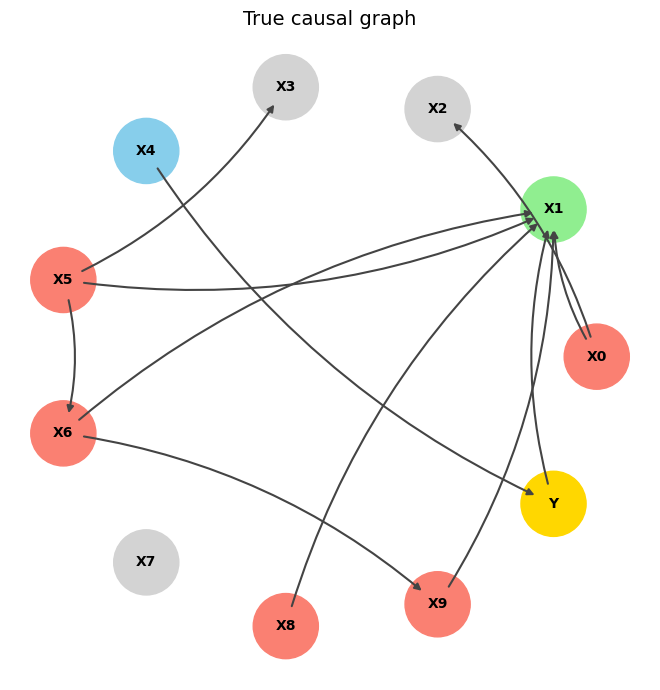

Number of variables: 11 (X0...X9 + Y)
True parents of Y: [4]
True children of Y: [1]
True spouses of Y: [5]


In [3]:
# Create an SCM with 10 variables + target Y
d = 10
scm = SCMGenerator(d=d)
scm.fit(n_parents=1, n_childs=1, n_spouses=1, sparsity=0.2, noise_type='uniform')

# Visualize the true graph
plot_graphs_from_adj([scm.A], Y_idx_list=[d], plot_titles=['True causal graph'])

print(f"Number of variables: {d + 1} (X0...X{d-1} + Y)")
print(f"True parents of Y: {scm.parents_idx}")
print(f"True children of Y: {scm.children_idx}")
print(f"True spouses of Y: {scm.spouses_idx}")


In [4]:
# Sample from the SCM
data = scm.sample(n_samples=10000)
data.head()


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,Y
0,0.194004,1.883044,-0.141706,0.035039,0.666322,0.197740,0.032471,0.321692,0.964543,0.150510,-1.006006
1,0.599281,-1.867911,0.526914,0.856349,-0.588413,0.701971,1.135221,0.371437,-0.812134,1.127060,0.797402
2,-0.825262,-0.416781,-0.511361,0.680111,0.461360,0.481501,0.464377,-0.648715,0.894778,0.859475,-0.137822
3,0.925724,1.877040,0.954501,0.440363,0.606828,0.712431,0.497776,-0.237073,0.536256,0.267554,-0.836502
4,0.297747,-0.399026,0.580159,0.052069,-0.913742,-0.007789,0.100876,-0.589675,0.797014,0.030713,1.379602


### 2.5 Step 1 — Empirical CI oracle: read the graph from data before running any algorithm

Just as in Section 1.5, the first step is to look at the data directly. For an 11-variable graph the number of variable pairs is large, so we focus on:

1. A **heatmap of pairwise marginal p-values** (Fisher z-test, no conditioning).  
2. A **skeleton estimate**: pairs whose marginal correlation is significant at α = 0.05.

This gives us a first approximation of the skeleton before any algorithm runs. We can then ask: which pairs are *definitely* adjacent? Which are *likely* confounded (dependent marginally but not directly connected)?

> **Note:** marginal tests alone cannot distinguish direct edges from indirect paths. The CI oracle is only complete when we also run conditional tests — which is exactly what PC does automatically.


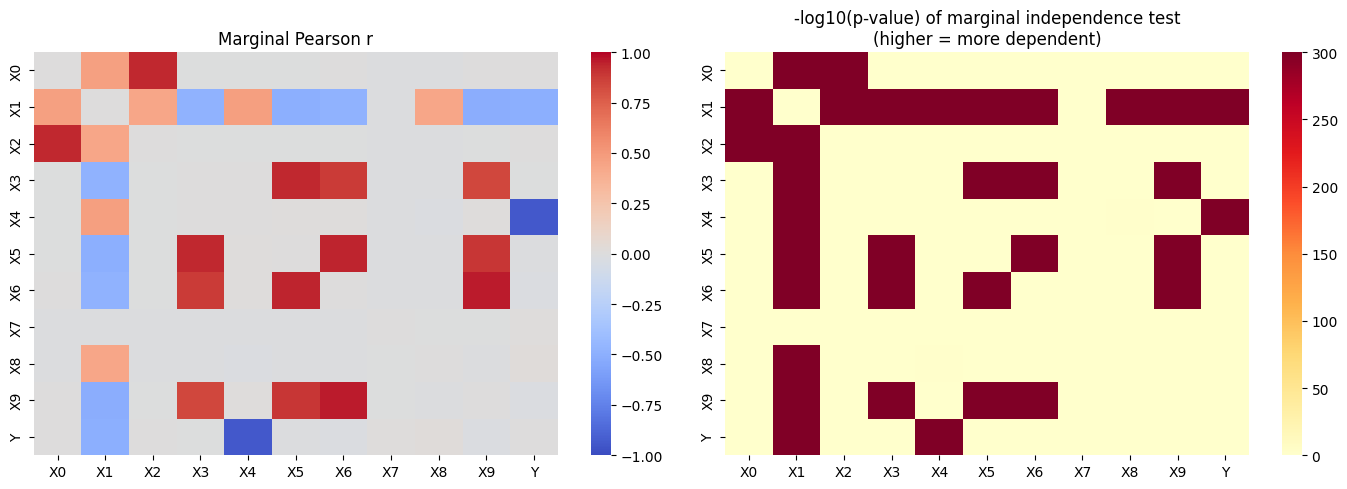


Marginal skeleton at α=0.05 (pairs with p < α):
  X0 — X1   (p=0.0000)
  X0 — X2   (p=0.0000)
  X1 — X2   (p=0.0000)
  X1 — X3   (p=0.0000)
  X1 — X4   (p=0.0000)
  X1 — X5   (p=0.0000)
  X1 — X6   (p=0.0000)
  X1 — X8   (p=0.0000)
  X1 — X9   (p=0.0000)
  X1 — Y   (p=0.0000)
  X3 — X5   (p=0.0000)
  X3 — X6   (p=0.0000)
  X3 — X9   (p=0.0000)
  X4 — Y   (p=0.0000)
  X5 — X6   (p=0.0000)
  X5 — X9   (p=0.0000)
  X6 — X9   (p=0.0000)

Total marginal edges: 17  |  True edges: 11


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm as scipy_norm

col_names = list(data.columns)
n_vars = len(col_names)

# -------------------------------------------------------
# Compute all pairwise marginal Fisher z p-values
# -------------------------------------------------------
def marginal_pval_matrix(df):
    cols = list(df.columns)
    n = len(df)
    X_np = df.values.astype(float)
    p_mat = np.ones((len(cols), len(cols)))
    r_mat = np.zeros((len(cols), len(cols)))
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = np.corrcoef(X_np[:, i], X_np[:, j])[0, 1]
            r = np.clip(r, -1 + 1e-9, 1 - 1e-9)
            z = np.arctanh(r)
            se = 1.0 / np.sqrt(n - 3)
            p = 2 * (1 - scipy_norm.cdf(abs(z) / se))
            p_mat[i, j] = p_mat[j, i] = p
            r_mat[i, j] = r_mat[j, i] = r
    return r_mat, p_mat

r_mat, p_mat = marginal_pval_matrix(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
sns.heatmap(r_mat, ax=axes[0], cmap='coolwarm', center=0, vmin=-1, vmax=1,
            xticklabels=col_names, yticklabels=col_names, annot=False)
axes[0].set_title('Marginal Pearson r')

# -log10(p) heatmap — high values = significant dependence
log_p = -np.log10(p_mat + 1e-300)
np.fill_diagonal(log_p, 0)
sns.heatmap(log_p, ax=axes[1], cmap='YlOrRd',
            xticklabels=col_names, yticklabels=col_names, annot=False)
axes[1].set_title('-log10(p-value) of marginal independence test\n(higher = more dependent)')

plt.tight_layout()
plt.show()

# Print the marginal skeleton (edges significant at alpha=0.05)
alpha_skel = 0.05
print(f'\nMarginal skeleton at α={alpha_skel} (pairs with p < α):')
edges_found = []
for i in range(n_vars):
    for j in range(i+1, n_vars):
        if p_mat[i, j] < alpha_skel:
            edges_found.append((col_names[i], col_names[j], p_mat[i,j]))
for e in edges_found:
    print(f'  {e[0]} — {e[1]}   (p={e[2]:.4f})')
print(f'\nTotal marginal edges: {len(edges_found)}  |  True edges: {int((scm.A > 0).sum())}')


### 2.6 Step 2 — Run PC and GES and compare to ground truth

We run both algorithms on the full dataset (n=10,000) at α=0.05.


Depth=4, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 726.47it/s]

PC   : 0.17s


GES  : 2.11s


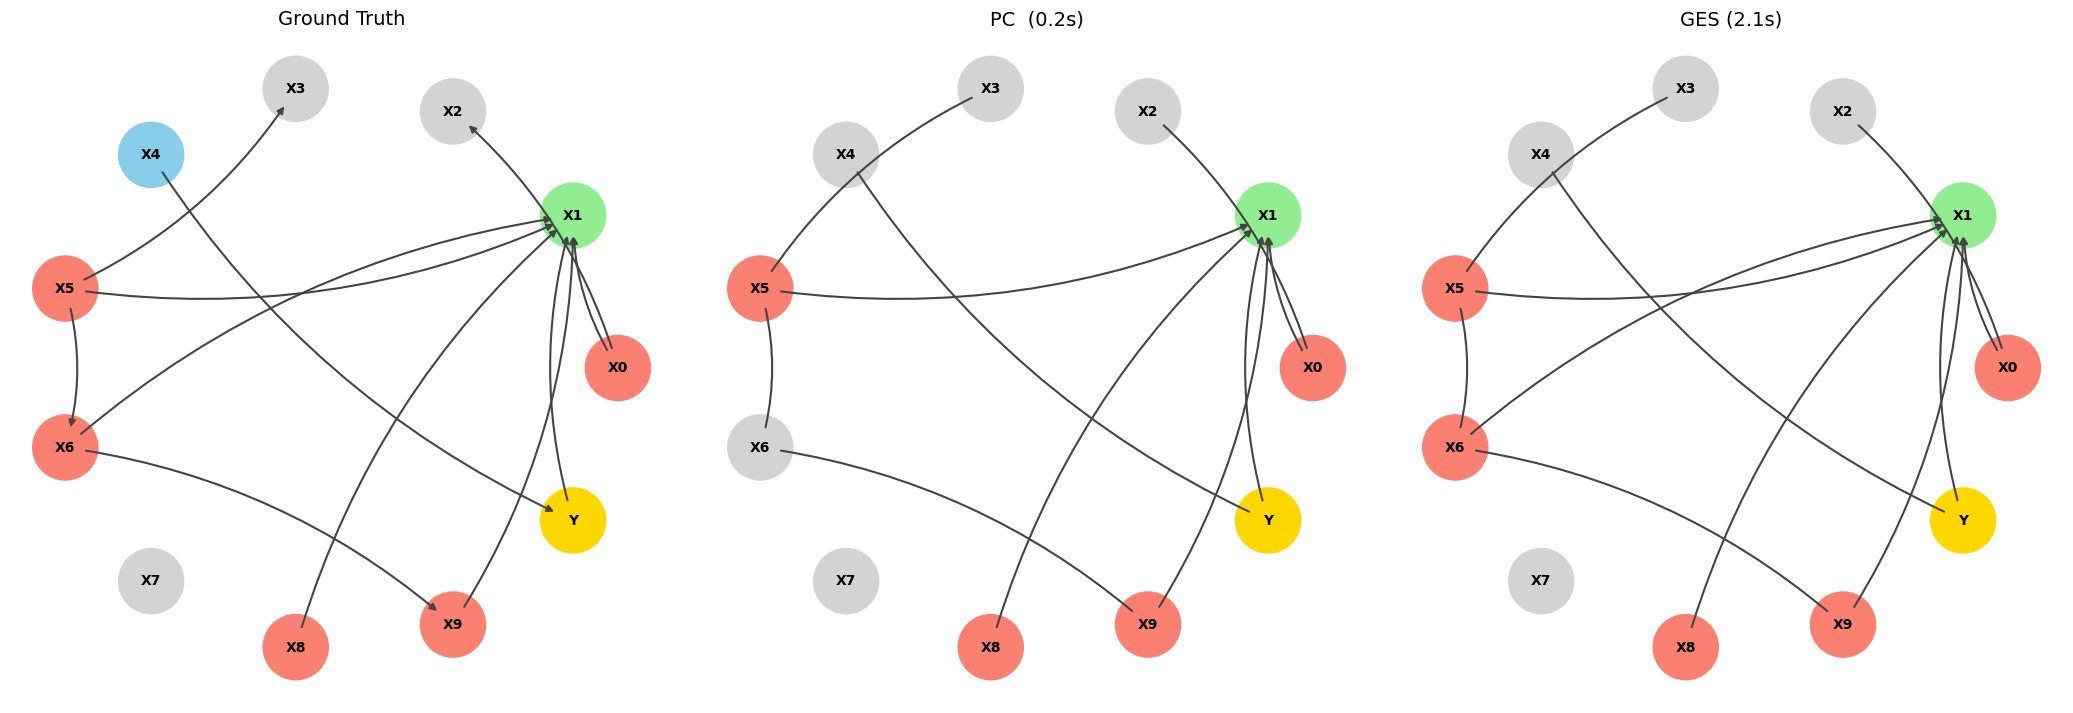

In [6]:
X_full = data.values

# PC
start = time.time()
cg_pc = pc(X_full, alpha=0.05, indep_test=fisherz)
A_pc = get_adjacency_pc(cg_pc, col_names)
time_pc = time.time() - start
print(f'PC   : {time_pc:.2f}s')

# GES (BIC)
start = time.time()
record_ges = ges(X_full)
A_ges = get_adjacency_ges(record_ges, col_names)
time_ges = time.time() - start
print(f'GES  : {time_ges:.2f}s')

# Plot
plot_graphs_from_adj(
    [scm.A, A_pc.values, A_ges.values],
    Y_idx_list=[d, d, d],
    plot_titles=['Ground Truth', f'PC  ({time_pc:.1f}s)', f'GES ({time_ges:.1f}s)']
)


In [7]:
def graph_metrics(A_true, A_pred, label=''):
    """
    Compute skeleton-level precision, recall, F1 and SHD.
    We symmetrise both matrices (treat directed and undirected edges alike).
    """
    true  = ((A_true  + A_true.T)  > 0).astype(int)
    pred  = ((A_pred  + A_pred.T)  > 0).astype(int)
    np.fill_diagonal(true, 0); np.fill_diagonal(pred, 0)

    # Only upper triangle to avoid double counting
    mask = np.triu(np.ones_like(true, dtype=bool), k=1)
    t, p = true[mask], pred[mask]

    tp = int(((p == 1) & (t == 1)).sum())
    fp = int(((p == 1) & (t == 0)).sum())
    fn = int(((p == 0) & (t == 1)).sum())

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    shd       = fp + fn   # Structural Hamming Distance (skeleton level)

    # print(f'{label:<30}  Prec={precision:.2f}  Rec={recall:.2f}  F1={f1:.2f}  SHD={shd}')
    return {'precision': precision, 'recall': recall, 'f1': f1, 'shd': shd}

print('Skeleton metrics (n=10 000):')
print('-' * 65)
m_pc  = graph_metrics(scm.A, A_pc.values,  'PC  (α=0.05)')
m_ges = graph_metrics(scm.A, A_ges.values, 'GES (BIC)')


Skeleton metrics (n=10 000):
-----------------------------------------------------------------


### 2.7 Step 3 — Effect of sample size on PC vs GES

Both algorithms degrade with fewer samples, but in different ways:
- **PC** degrades because individual CI tests lose power — edges are incorrectly kept or removed.
- **GES** degrades because the BIC score becomes a noisier estimate of the true likelihood — local greedy moves may follow noise.

We run both algorithms at five sample sizes on the **same SCM** (same true graph) and plot F1 and SHD as a function of n.


In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Parameters
d_values = [5, 10, 20]
sample_sizes = [100, 300, 500]
n_reps = 1
results_list = []

for d in d_values:
    print(f"Processing d = {d}...")
    col_names = [f"V{i}" for i in range(d+1)]
    for n in sample_sizes:
        for rep in range(n_reps):
            np.random.seed(rep * 17 + d)
            # 1. Generate SCM
            scm = SCMGenerator(d=d)
            scm.fit(n_parents=1, n_childs=1, n_spouses=1, sparsity=0.2, noise_type='uniform')
            df_sub = scm.sample(n_samples=n)
            X_sub  = df_sub.values

            # 2. Run PC
            cg_sub = pc(X_sub, alpha=0.05, indep_test=fisherz)
            A_pc = get_adjacency_pc(cg_sub, col_names).values
            m_pc = graph_metrics(scm.A, A_pc)

            # 3. Run GES
            rec_sub = ges(X_sub)
            A_ges = get_adjacency_ges(rec_sub, col_names).values
            m_ges = graph_metrics(scm.A, A_ges)

            results_list.append({
                'd': d, 'n': n, 
                'pc_f1': m_pc['f1'], 'pc_shd': m_pc['shd'],
                'ges_f1': m_ges['f1'], 'ges_shd': m_ges['shd']
            })

# Aggregating results
df_results = pd.DataFrame(results_list)
summary = df_results.groupby(['d', 'n']).mean().reset_index()

Processing d = 5...


Depth=1, working on node 5: 100%|██████████| 6/6 [00:00<00:00, 631.86it/s] 


Processing d = 10...


Depth=2, working on node 10: 100%|██████████| 11/11 [00:00<00:00, 663.86it/s]


Processing d = 20...


Depth=3, working on node 20: 100%|██████████| 21/21 [00:00<00:00, 515.75it/s]


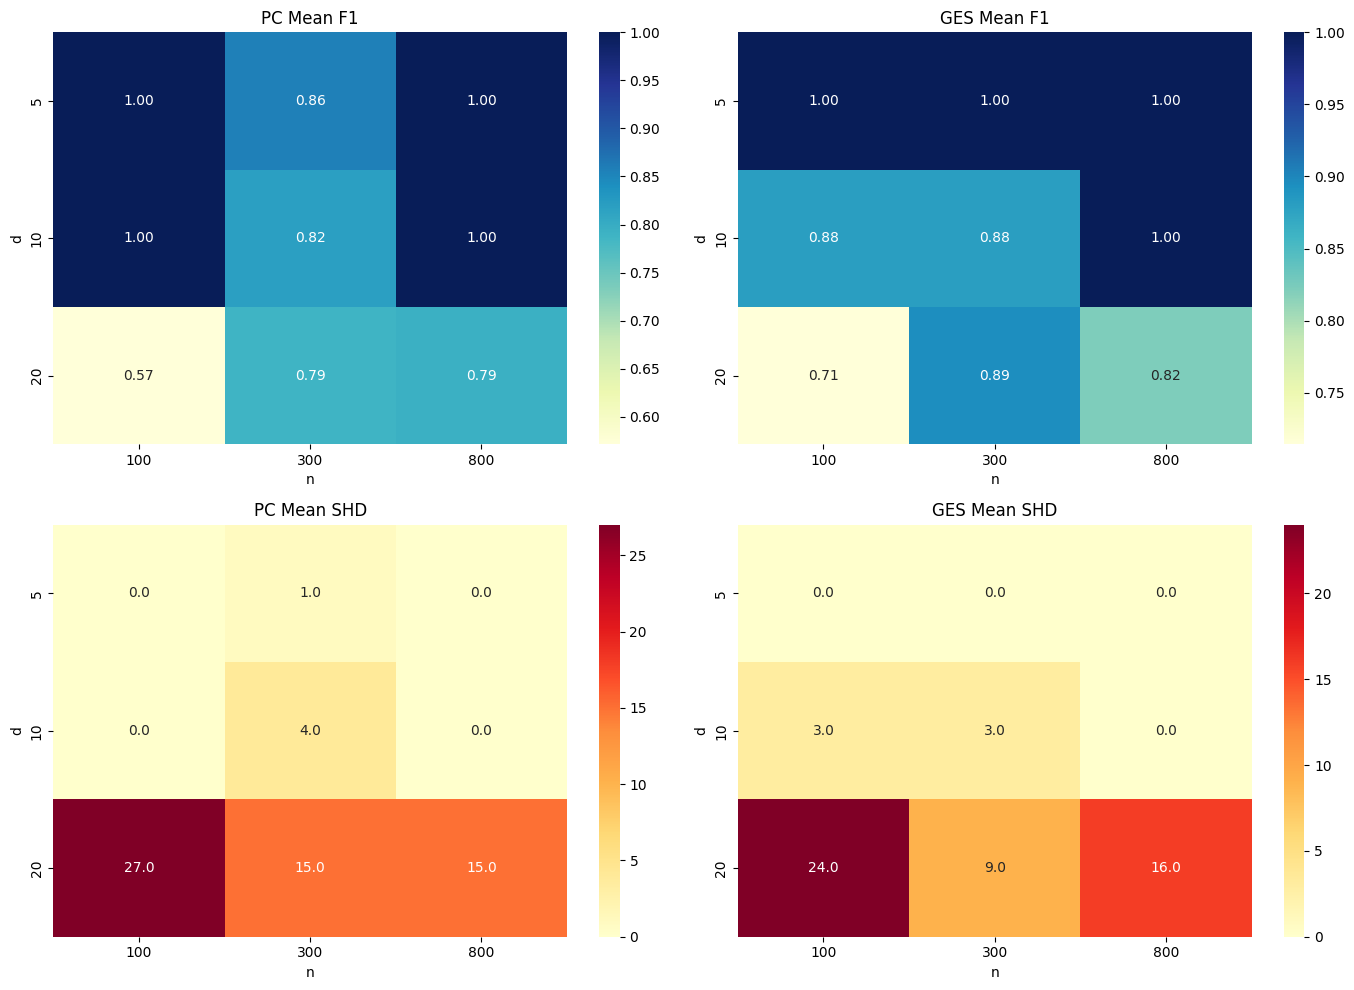

In [ ]:
# Plotting Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, metric in enumerate(['f1', 'shd']):
    for j, algo in enumerate(['pc', 'ges']):
        col = f'{algo}_{metric}'
        pivot = summary.pivot(index="d", columns="n", values=col)
        sns.heatmap(pivot, annot=True, fmt=".2f" if metric=='f1' else ".1f", 
                    cmap="YlGnBu" if metric=='f1' else "YlOrRd", ax=axes[i, j])
        axes[i, j].set_title(f"{algo.upper()} Mean {metric.upper()}")

plt.tight_layout()
plt.show()

Depth=3, working on node 20: 100%|██████████| 21/21 [00:00<00:00, 712.01it/s]


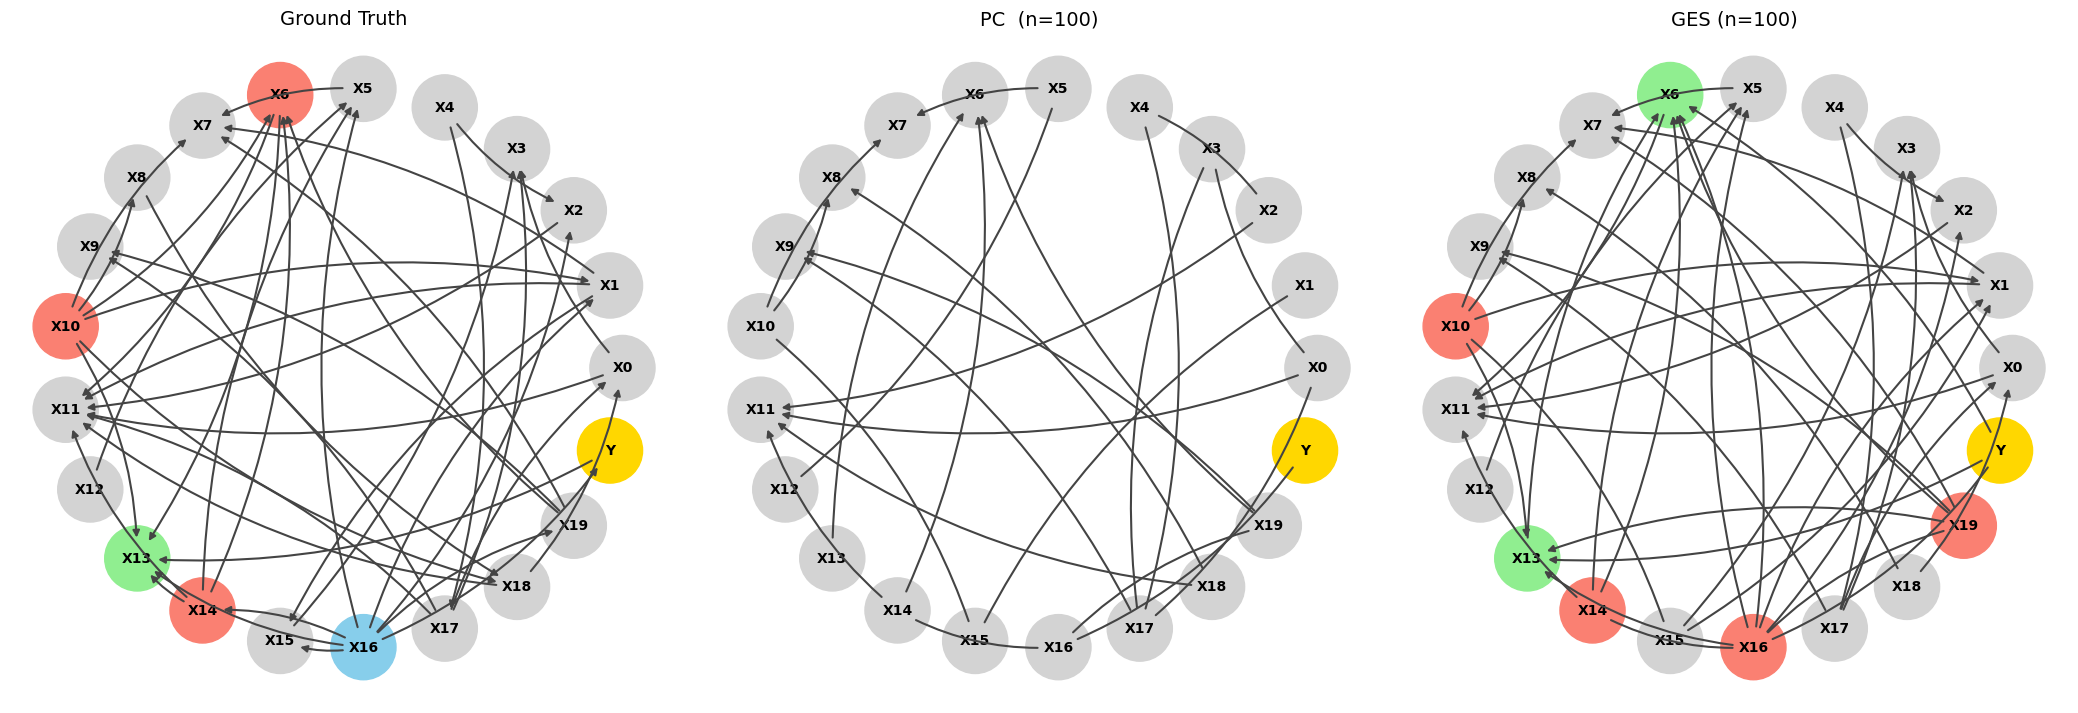

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [ ]:
# Show recovered graphs at the two extremes: n=100 and n=10 000
np.random.seed(0)
df_small = scm.sample(n_samples=100)
X_small  = df_small.values

cg_small_pc  = pc(X_small, alpha=0.05, indep_test=fisherz)
rec_small_ges = ges(X_small)

A_pc_small  = get_adjacency_pc(cg_small_pc,   col_names).values
A_ges_small = get_adjacency_ges(rec_small_ges, col_names).values

plot_graphs_from_adj(
    [scm.A,      A_pc_small,       A_ges_small],
    Y_idx_list=[d, d, d],
    plot_titles=['Ground Truth', 'PC  (n=100)', 'GES (n=100)']
)

plot_graphs_from_adj(
    [scm.A,     A_pc.values,          A_ges.values],
    Y_idx_list=[d, d, d],
    plot_titles=['Ground Truth', 'PC  (n=10 000)', 'GES (n=10 000)']
)


### Exercise 2 — Effect of sample size

Re-run the three algorithms with `n_samples = 500` instead of 5000. How does graph recovery degrade? Which algorithm is most robust to small samples? Can you explain why?


In [ ]:
# Your code here
# d = 10
# scm_small = SCMGenerator(d=d)
# scm_small.fit(n_parents=1, n_childs=1, n_spouses=1, sparsity=0.2, noise_type='uniform')
# data_small = scm_small.sample(n_samples=500)
# ...
